# Multi-corpus exploratory data analysis

This notebook checks every normalized corpus before training: UCI SMS, Enron-Spam, SpamAssassin, Nazario, and the local Kaggle phishing compilation. It reports class balance, duplicate counts, missing values, text-length distributions, and exact cross-corpus text overlap. The hand-curated chat evaluation set remains reserved for later slices.

In [1]:
# Import Path so the notebook works from its own directory.
from pathlib import Path

# Import Matplotlib for explicit figure construction.
import matplotlib.pyplot as plt
# Import pandas for labeled tabular analysis.
import pandas as pd
# Import Seaborn for readable statistical charts.
import seaborn as sns

# Resolve the ML project root from the notebooks directory.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
# Point at the ignored processed-directory that stores normalized CSVs.
PROCESSED_DIRECTORY = PROJECT_ROOT / "data" / "processed"
# Map each corpus key to its normalized CSV filename.
CORPUS_FILES = {
    # Keep the Slice 1 SMS corpus in the multi-corpus comparison.
    "uci_sms_spam": "sms_spam.csv",
    # Include the Metsis Enron-Spam derivative.
    "enron_spam": "enron_spam.csv",
    # Include the Apache SpamAssassin public corpus.
    "spamassassin": "spamassassin.csv",
    # Include Jose Nazario's phishing-only snapshots.
    "nazario": "nazario.csv",
    # Include the locally supplied Kaggle phishing compilation.
    "kaggle_phishing": "kaggle_phishing.csv",
}
# Map corpus keys to the preparation commands operators must run first.
PREP_COMMANDS = {
    # Document the UCI SMS preparation entry point.
    "uci_sms_spam": "uv run python scripts/download_sms_spam.py",
    # Document the Enron-Spam preparation entry point.
    "enron_spam": "uv run python scripts/download_enron_spam.py",
    # Document the SpamAssassin preparation entry point.
    "spamassassin": "uv run python scripts/download_spamassassin.py",
    # Document the Nazario preparation entry point.
    "nazario": "uv run python scripts/download_nazario.py",
    # Document the Kaggle normalization entry point.
    "kaggle_phishing": "uv run python scripts/download_kaggle_phishing.py",
}

# Load one normalized corpus and attach length diagnostics.
def load_corpus(source_key: str) -> pd.DataFrame:
    """Return one processed corpus with character and token counts."""

    # Resolve the expected CSV path for this corpus key.
    dataset_path = PROCESSED_DIRECTORY / CORPUS_FILES[source_key]
    # Stop with an actionable instruction when preparation has not run.
    if not dataset_path.exists():
        # Explain the exact command needed to create the local dataset.
        raise FileNotFoundError(f"Run: {PREP_COMMANDS[source_key]}")
    # Load message text as strings while preserving the integer target.
    frame = pd.read_csv(
        # Read the normalized CSV produced by the matching download script.
        dataset_path,
        # Keep text fields as pandas string dtype for length calculations.
        dtype={"text": "string", "original_label": "string", "source": "string", "split": "string"},
    )
    # Derive character length without mutating the original text.
    frame["character_count"] = frame["text"].str.len()
    # Derive whitespace-token count as a simple register diagnostic.
    frame["token_count"] = frame["text"].str.split().str.len()
    # Return the enriched frame for later aggregate reporting.
    return frame

# Load every available normalized corpus into a dictionary.
corpora = {source_key: load_corpus(source_key) for source_key in CORPUS_FILES}
# Concatenate corpora for cross-source duplicate analysis.
combined = pd.concat(corpora.values(), ignore_index=True)
# Display only aggregate shape information for the combined table.
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71813 entries, 0 to 71812
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   message_id       71813 non-null  object
 1   text             71813 non-null  string
 2   label            71813 non-null  int64 
 3   original_label   71813 non-null  string
 4   source           71813 non-null  string
 5   split            71813 non-null  string
 6   character_count  71813 non-null  Int64 
 7   token_count      71813 non-null  int64 
dtypes: Int64(1), int64(2), object(1), string(4)
memory usage: 4.5+ MB


In [2]:
# Build an aggregate quality report for one corpus.
def quality_report(frame: pd.DataFrame) -> dict:
    """Return class balance, duplicate, and missing-value diagnostics."""

    # Count examples in each canonical class.
    class_counts = frame["label"].value_counts().sort_index()
    # Convert class counts into proportions for imbalance assessment.
    class_proportions = frame["label"].value_counts(normalize=True).sort_index()
    # Count exact repeated text before any future train/test split.
    duplicate_texts = int(frame.duplicated(subset=["text"]).sum())
    # Count absent values that would invalidate vectorization.
    missing_values = frame[["text", "label"]].isna().sum()
    # Assemble the quality report from aggregate values only.
    return {
        # Record the complete normalized row count.
        "rows": len(frame),
        # Record class counts using readable labels.
        "class_counts": {
            "legitimate": int(class_counts.get(0, 0)),
            "scam": int(class_counts.get(1, 0)),
        },
        # Record proportions for threshold and stratification planning.
        "class_proportions": {
            "legitimate": float(class_proportions.get(0, 0.0)),
            "scam": float(class_proportions.get(1, 0.0)),
        },
        # Record exact duplicates that must not cross data splits.
        "duplicate_texts": duplicate_texts,
        # Record missing values by required field.
        "missing_values": missing_values.to_dict(),
        # Record median character length as a domain-shift diagnostic.
        "median_character_count": float(frame["character_count"].median()),
        # Record median token count as a second length diagnostic.
        "median_token_count": float(frame["token_count"].median()),
    }

# Compute one quality report per corpus key.
reports = {source_key: quality_report(frame) for source_key, frame in corpora.items()}
# Render the multi-corpus quality table as the cell result.
pd.DataFrame(reports).T

,rows,class_counts,class_proportions,duplicate_texts,missing_values,median_character_count,median_token_count
uci_sms_spam,5574,"{'legitimate': 4827, 'scam': 747}","{'legitimate': 0.8659849300322928, 'scam': 0.1...",403,"{'text': 0, 'label': 0}",62.0,12.0
enron_spam,33344,"{'legitimate': 16493, 'scam': 16851}","{'legitimate': 0.4946317178502879, 'scam': 0.5...",3979,"{'text': 0, 'label': 0}",687.5,148.0
spamassassin,6029,"{'legitimate': 4150, 'scam': 1879}","{'legitimate': 0.6883396914911262, 'scam': 0.3...",295,"{'text': 0, 'label': 0}",981.0,147.0
nazario,8235,"{'legitimate': 0, 'scam': 8235}","{'legitimate': 0.0, 'scam': 1.0}",2443,"{'text': 0, 'label': 0}",956.0,142.0
kaggle_phishing,18631,"{'legitimate': 11322, 'scam': 7309}","{'legitimate': 0.6076968493371263, 'scam': 0.3...",1109,"{'text': 0, 'label': 0}",882.0,160.0


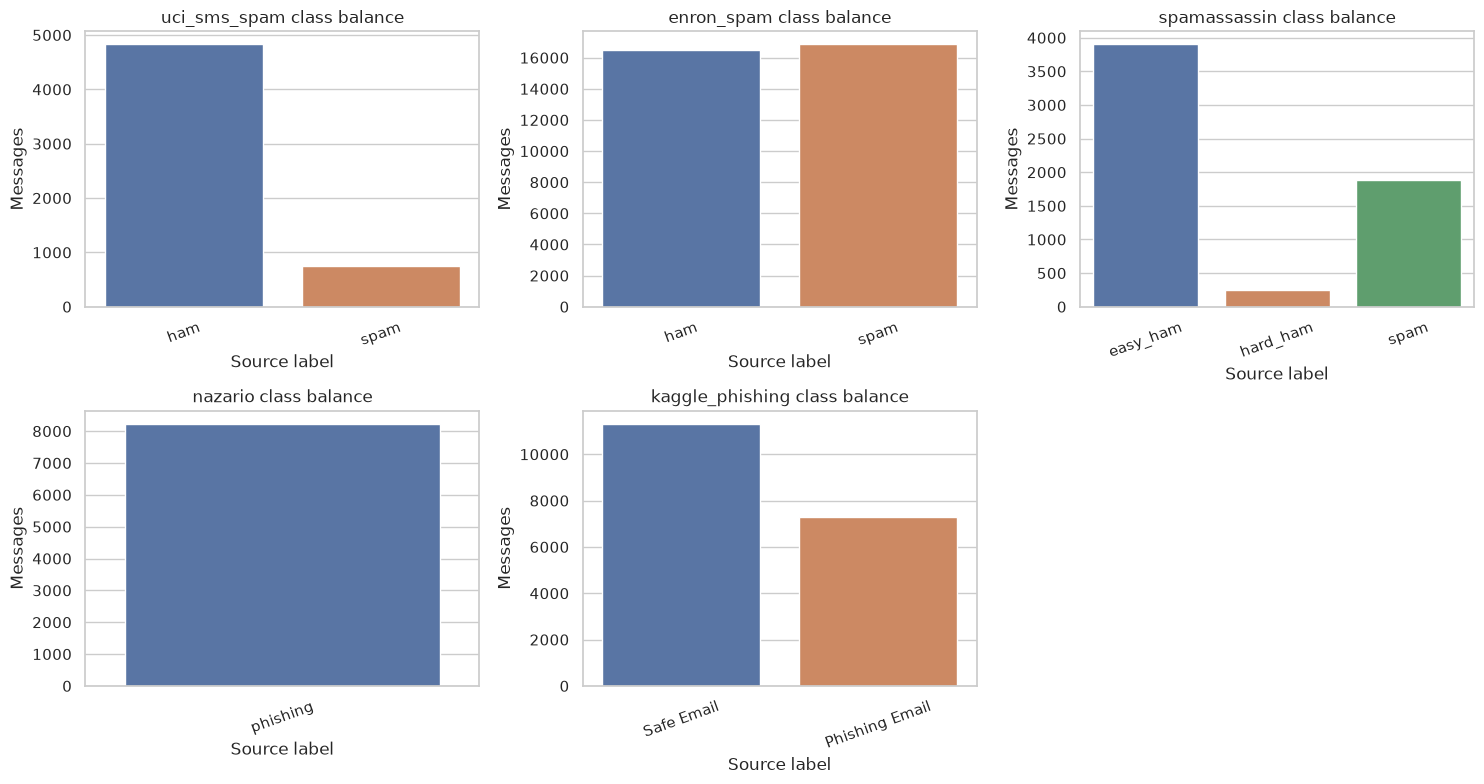

In [3]:
# Give plots a consistent accessible visual theme.
sns.set_theme(style="whitegrid")
# Create one balance panel for each normalized corpus.
figure, axes = plt.subplots(2, 3, figsize=(15, 8))
# Flatten the axes grid for simple sequential indexing.
flat_axes = axes.flatten()
# Plot class balance for every loaded corpus.
for index, (source_key, frame) in enumerate(corpora.items()):
    # Draw a count plot over the preserved original labels.
    sns.countplot(
        # Use the current corpus frame as the plotting source.
        data=frame,
        # Plot the human-readable source labels on the x-axis.
        x="original_label",
        # Color bars by label without adding a redundant legend.
        hue="original_label",
        # Suppress the duplicate legend for compact multi-panel figures.
        legend=False,
        # Target the next subplot in reading order.
        ax=flat_axes[index],
    )
    # Title the panel with the corpus key.
    flat_axes[index].set_title(f"{source_key} class balance")
    # Rotate labels so long Kaggle class names remain readable.
    flat_axes[index].tick_params(axis="x", rotation=20)
    # Label the categorical source target axis.
    flat_axes[index].set_xlabel("Source label")
    # Label the sample-count axis.
    flat_axes[index].set_ylabel("Messages")
# Hide the unused sixth subplot in the 2x3 grid.
flat_axes[-1].axis("off")
# Prevent labels from overlapping within the saved notebook view.
figure.tight_layout()
# Display the complete class-balance figure.
plt.show()

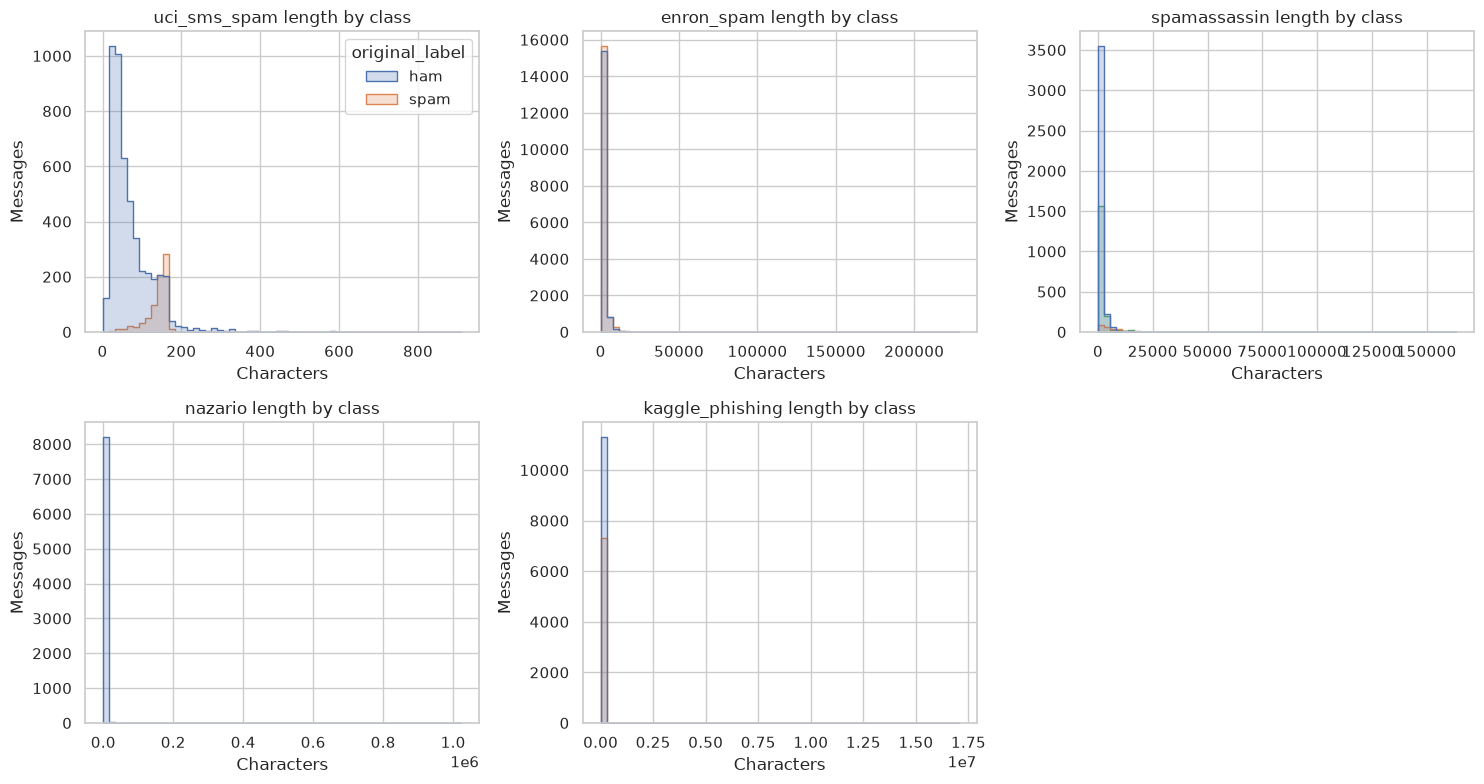

In [4]:
# Create one length-distribution panel for each normalized corpus.
figure, axes = plt.subplots(2, 3, figsize=(15, 8))
# Flatten the axes grid for simple sequential indexing.
flat_axes = axes.flatten()
# Plot character-count histograms for every loaded corpus.
for index, (source_key, frame) in enumerate(corpora.items()):
    # Compare character-count distributions without showing message content.
    sns.histplot(
        # Use the current corpus frame as the plotting source.
        data=frame,
        # Plot character counts on the x-axis.
        x="character_count",
        # Color by the preserved original label.
        hue="original_label",
        # Use enough bins to show long-tail email lengths.
        bins=60,
        # Prefer step outlines for overlapping class distributions.
        element="step",
        # Target the next subplot in reading order.
        ax=flat_axes[index],
        # Keep legends compact inside multi-panel charts.
        legend=index == 0,
    )
    # Title the panel with the corpus key.
    flat_axes[index].set_title(f"{source_key} length by class")
    # Label the measured length unit.
    flat_axes[index].set_xlabel("Characters")
    # Label the frequency axis.
    flat_axes[index].set_ylabel("Messages")
# Hide the unused sixth subplot in the 2x3 grid.
flat_axes[-1].axis("off")
# Prevent labels from overlapping within the saved notebook view.
figure.tight_layout()
# Display the complete length-distribution figure.
plt.show()

In [5]:
# Build a set of exact texts for each corpus to measure pairwise overlap.
text_sets = {
    # Convert each corpus text column into a Python set of unique strings.
    source_key: set(frame["text"].dropna().astype(str))
    # Iterate every loaded corpus in deterministic key order.
    for source_key, frame in corpora.items()
}
# Collect pairwise exact-overlap counts for the provenance risk check.
overlap_rows = []
# Compare every unordered pair of corpora exactly once.
source_keys = list(text_sets)
# Walk the upper triangle of the corpus-by-corpus matrix.
for left_index, left_key in enumerate(source_keys):
    # Compare the current corpus only against later corpora.
    for right_key in source_keys[left_index + 1 :]:
        # Count texts that appear verbatim in both corpora.
        shared = len(text_sets[left_key] & text_sets[right_key])
        # Record the pair and shared-text count for display.
        overlap_rows.append(
            {
                # Name the first corpus in the compared pair.
                "corpus_a": left_key,
                # Name the second corpus in the compared pair.
                "corpus_b": right_key,
                # Store the exact shared unique-text count.
                "shared_unique_texts": shared,
            }
        )
# Render the pairwise overlap table as the cell result.
pd.DataFrame(overlap_rows).sort_values("shared_unique_texts", ascending=False)

,corpus_a,corpus_b,shared_unique_texts
6,enron_spam,kaggle_phishing,67
8,spamassassin,kaggle_phishing,11
5,enron_spam,nazario,2
4,enron_spam,spamassassin,1
1,uci_sms_spam,spamassassin,0
0,uci_sms_spam,enron_spam,0
2,uci_sms_spam,nazario,0
3,uci_sms_spam,kaggle_phishing,0
7,spamassassin,nazario,0
9,nazario,kaggle_phishing,0


In [6]:
# Summarize combined multi-corpus scale without exposing plaintext.
combined_summary = {
    # Record the total number of normalized rows across all sources.
    "total_rows": int(len(combined)),
    # Record combined class counts for later stratification planning.
    "class_counts": combined["label"].value_counts().sort_index().to_dict(),
    # Record how many unique texts survive exact deduplication.
    "unique_texts": int(combined["text"].nunique(dropna=True)),
    # Record exact duplicate rows across the union of all corpora.
    "duplicate_texts_across_union": int(combined.duplicated(subset=["text"]).sum()),
    # Record per-source contribution counts.
    "rows_by_source": combined["source"].value_counts().to_dict(),
}
# Render the combined summary as the cell result.
combined_summary

{'total_rows': 71813,
 'class_counts': {0: 36792, 1: 35021},
 'unique_texts': 63504,
 'duplicate_texts_across_union': 8309,
 'rows_by_source': {'enron_spam': 33344,
  'kaggle_phishing': 18631,
  'nazario': 8235,
  'spamassassin': 6029,
  'uci_sms_spam': 5574}}